## Sleep Health and Lifestyle Analysis  

### Step 1:Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Step 2:Loading DataSet

In [2]:
sleep_df = pd.read_csv(r"C:\Users\mohin\Downloads\sleep_health_lifestyle_dataset (1).csv")

### Step 3:Previewing Data and Size

In [3]:
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia


In [4]:
sleep_df.shape

(400, 13)

 ### Step 3: Initial Insights

In [5]:
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Person ID                              400 non-null    int64  
 1   Gender                                 400 non-null    object 
 2   Age                                    400 non-null    int64  
 3   Occupation                             400 non-null    object 
 4   Sleep Duration (hours)                 400 non-null    float64
 5   Quality of Sleep (scale: 1-10)         400 non-null    float64
 6   Physical Activity Level (minutes/day)  400 non-null    int64  
 7   Stress Level (scale: 1-10)             400 non-null    int64  
 8   BMI Category                           400 non-null    object 
 9   Blood Pressure (systolic/diastolic)    400 non-null    object 
 10  Heart Rate (bpm)                       400 non-null    int64  
 11  Daily 

### Step 4: Checking Null Values 

In [6]:
sleep_df.isnull().sum()

Person ID                                  0
Gender                                     0
Age                                        0
Occupation                                 0
Sleep Duration (hours)                     0
Quality of Sleep (scale: 1-10)             0
Physical Activity Level (minutes/day)      0
Stress Level (scale: 1-10)                 0
BMI Category                               0
Blood Pressure (systolic/diastolic)        0
Heart Rate (bpm)                           0
Daily Steps                                0
Sleep Disorder                           290
dtype: int64

### Step 4: Fill the Null Values

In [7]:
sleep_df['Sleep Disorder'].fillna('No Sleep Disorder', inplace=True)

In [8]:
sleep_df.isnull().sum()

Person ID                                0
Gender                                   0
Age                                      0
Occupation                               0
Sleep Duration (hours)                   0
Quality of Sleep (scale: 1-10)           0
Physical Activity Level (minutes/day)    0
Stress Level (scale: 1-10)               0
BMI Category                             0
Blood Pressure (systolic/diastolic)      0
Heart Rate (bpm)                         0
Daily Steps                              0
Sleep Disorder                           0
dtype: int64

### Step 5: Statistical Analysis

In [9]:
sleep_df.describe()

,Person ID,Age,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),Heart Rate (bpm),Daily Steps
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000
mean,200.500000,39.950000,8.041250,6.125750,64.985000,5.47250,75.990000,11076.510000
std,115.614301,14.038883,2.390787,1.975733,32.297874,2.80873,15.099334,5364.789364
min,1.000000,18.000000,4.100000,1.000000,10.000000,1.00000,50.000000,2067.000000
25%,100.750000,29.000000,5.900000,4.700000,35.000000,3.00000,63.000000,6165.250000
50%,200.500000,40.000000,8.200000,6.100000,65.500000,5.00000,77.000000,11785.500000
75%,300.250000,49.000000,10.125000,7.425000,94.000000,8.00000,90.000000,15878.000000
max,400.000000,90.000000,12.000000,10.000000,120.000000,10.00000,100.000000,19958.000000


### Standardizing Data Formats

In [10]:
sleep_df[['Systolic BP', 'Diastolic BP']] = sleep_df['Blood Pressure (systolic/diastolic)'].str.split('/', expand=True)
sleep_df['Systolic BP'] = sleep_df['Systolic BP'].astype(float)
sleep_df['Diastolic BP'] = sleep_df['Diastolic BP'].astype(float)

In [11]:
sleep_df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
395,396,Female,36,Student,4.5,7.9,73,7,Normal,118/66,64,14497,Sleep Apnea,118.0,66.0
396,397,Female,45,Manual Labor,6.0,6.1,72,8,Obese,132/80,65,12848,Insomnia,132.0,80.0
397,398,Female,30,Student,5.3,6.5,58,10,Obese,125/76,66,15255,Insomnia,125.0,76.0
398,399,Female,41,Retired,11.0,9.1,73,9,Obese,130/75,75,6567,Sleep Apnea,130.0,75.0
399,400,Male,37,Retired,5.8,7.0,41,6,Normal,118/70,51,18079,No Sleep Disorder,118.0,70.0


In [12]:
sleep_df = sleep_df.drop(columns=['Blood Pressure (systolic/diastolic)'])

In [13]:
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Heart Rate (bpm),Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,91,8539,No Sleep Disorder,124.0,70.0
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,81,18754,No Sleep Disorder,131.0,86.0
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,81,2857,No Sleep Disorder,122.0,70.0
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,55,6886,No Sleep Disorder,124.0,72.0
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,97,14945,Insomnia,133.0,78.0


### Step 6: Outlier Detection with Boxplot

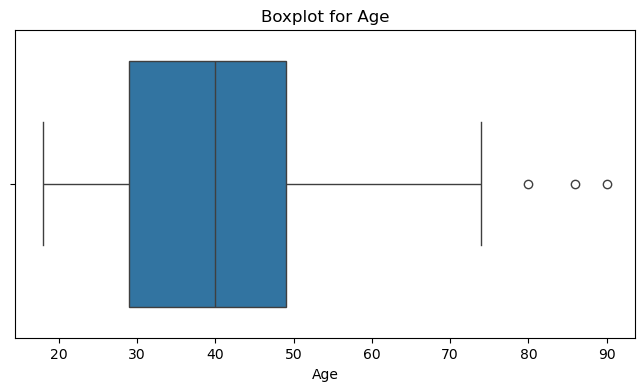

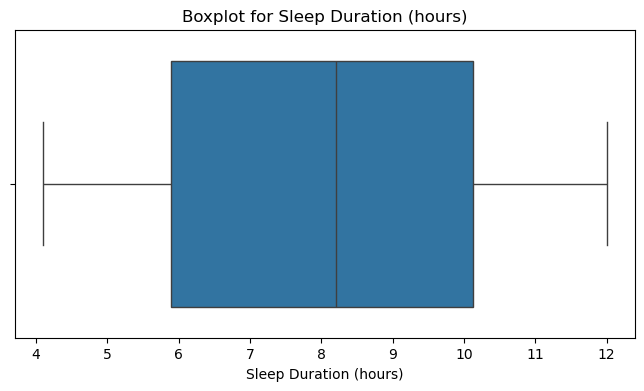

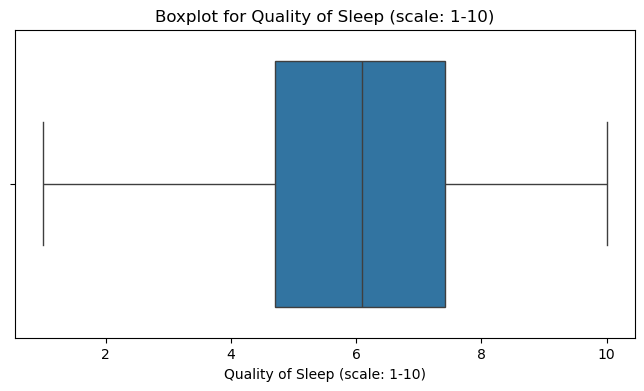

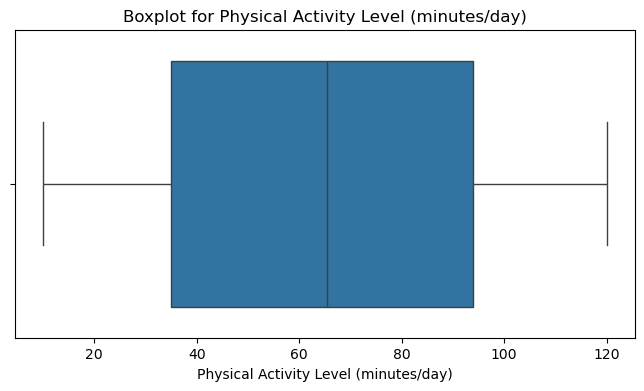

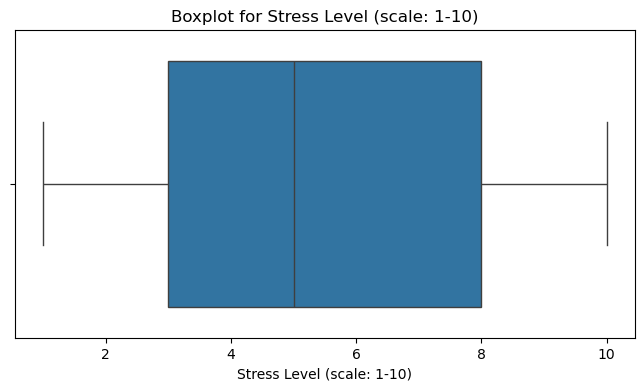

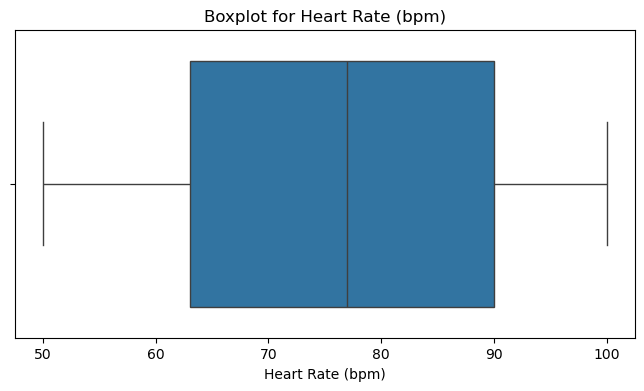

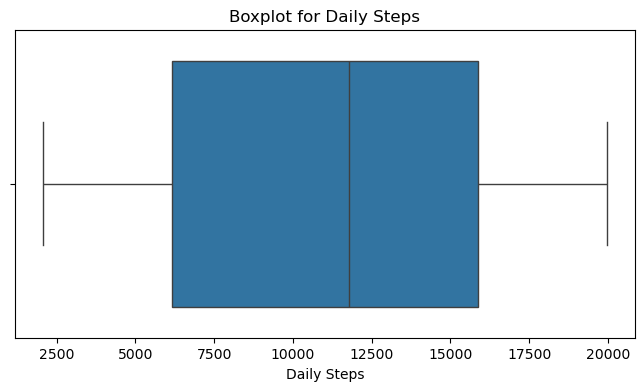

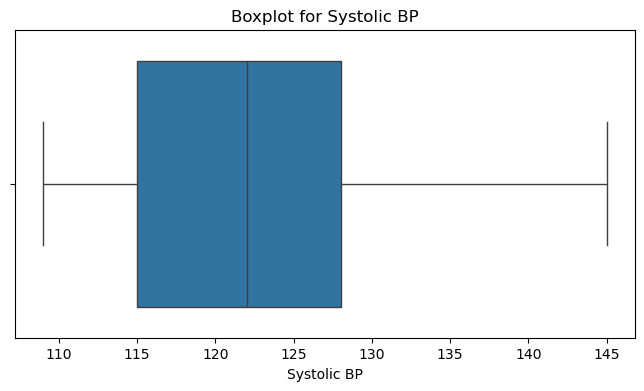

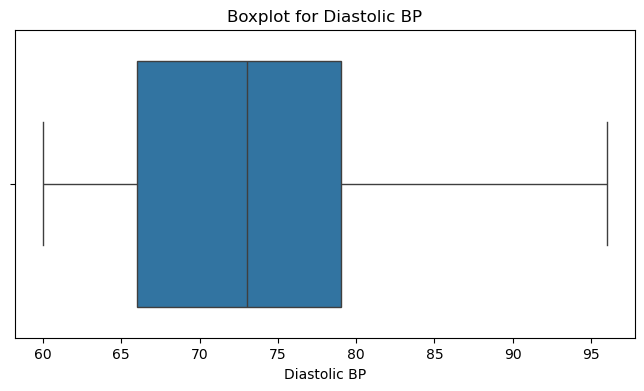

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to visualize outliers
outlier_columns = [
    'Age', 
    'Sleep Duration (hours)', 
    'Quality of Sleep (scale: 1-10)', 
    'Physical Activity Level (minutes/day)', 
    'Stress Level (scale: 1-10)', 
    'Heart Rate (bpm)', 
    'Daily Steps',
    'Systolic BP', 
    'Diastolic BP'
]

# Function to create boxplots
def plot_boxplots(df, columns):
    for column in columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=column)
        plt.title(f'Boxplot for {column}')
        plt.xlabel(column)
        plt.show()

# Call the function to plot boxplots
plot_boxplots(sleep_df, outlier_columns)


### Visualization

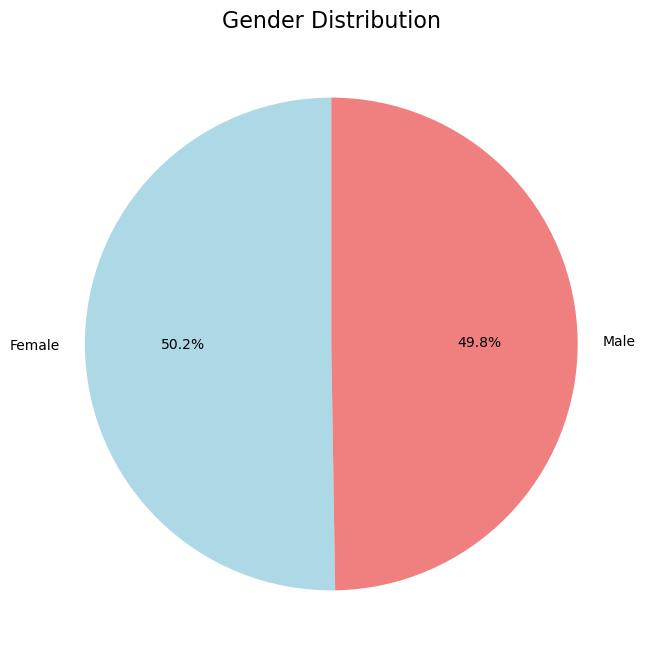

In [15]:
plt.figure(figsize=(8, 8))
gender_counts = sleep_df['Gender'].value_counts()

plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        colors=['lightblue', 'lightcoral'], 
        startangle=90)

plt.title('Gender Distribution', fontsize=16)

plt.show()


📋 Analyzing Categorical Features:


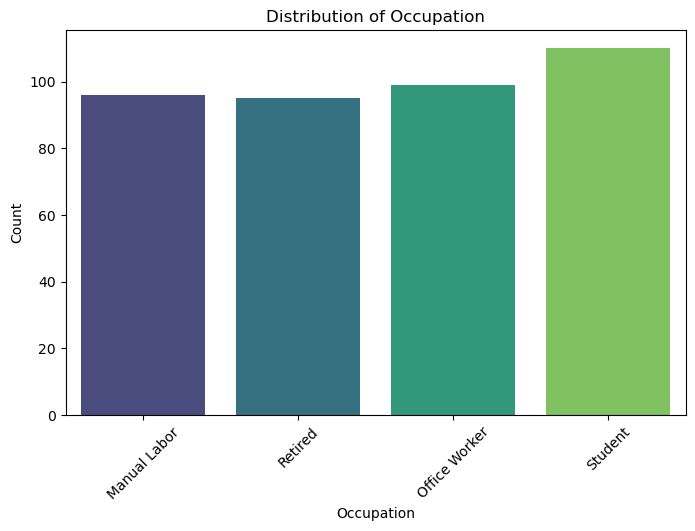

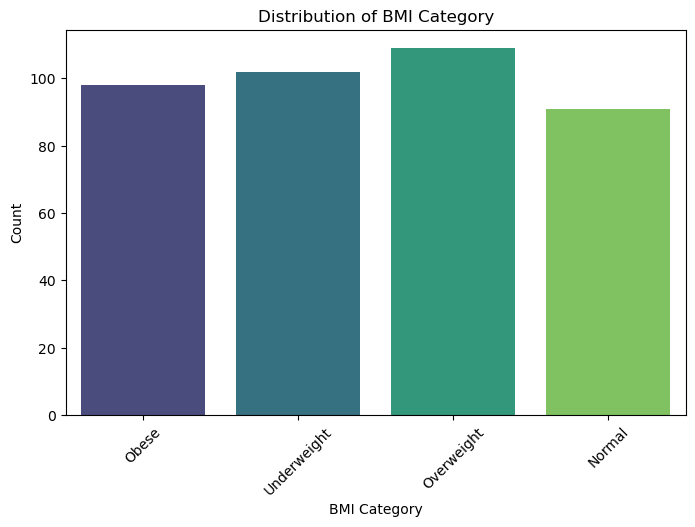

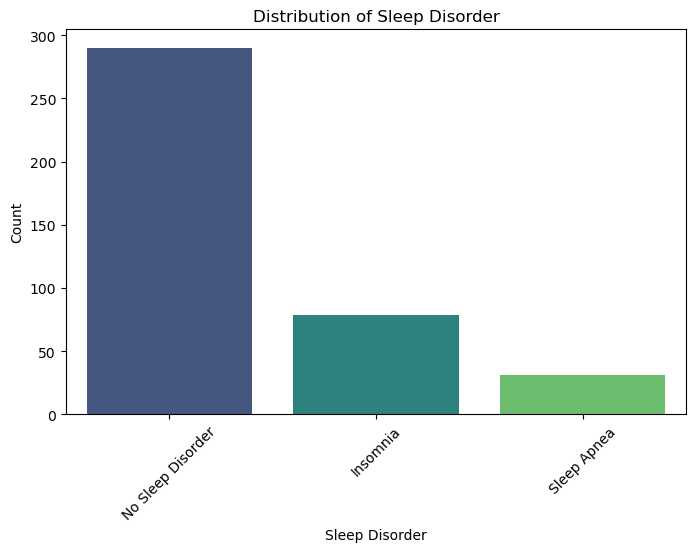

In [16]:
print("\n📋 Analyzing Categorical Features:")
categorical_features = [ 'Occupation', 'BMI Category', 'Sleep Disorder']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=sleep_df, x=feature, palette="viridis")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

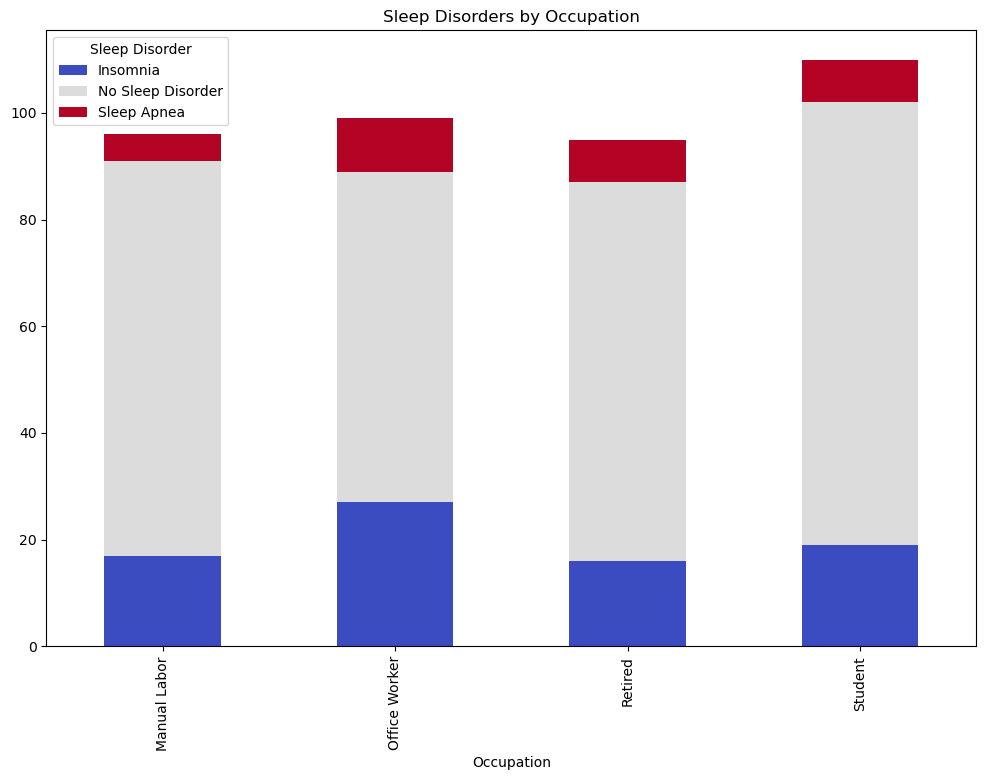

In [17]:
sleep_disorder_counts = sleep_df.groupby(['Occupation', 'Sleep Disorder']).size().unstack()

sleep_disorder_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='coolwarm')
plt.title('Sleep Disorders by Occupation')
plt.legend(title='Sleep Disorder')
plt.show()


🔍 Analyzing the Distribution of Sleep Disorders Across Categories:


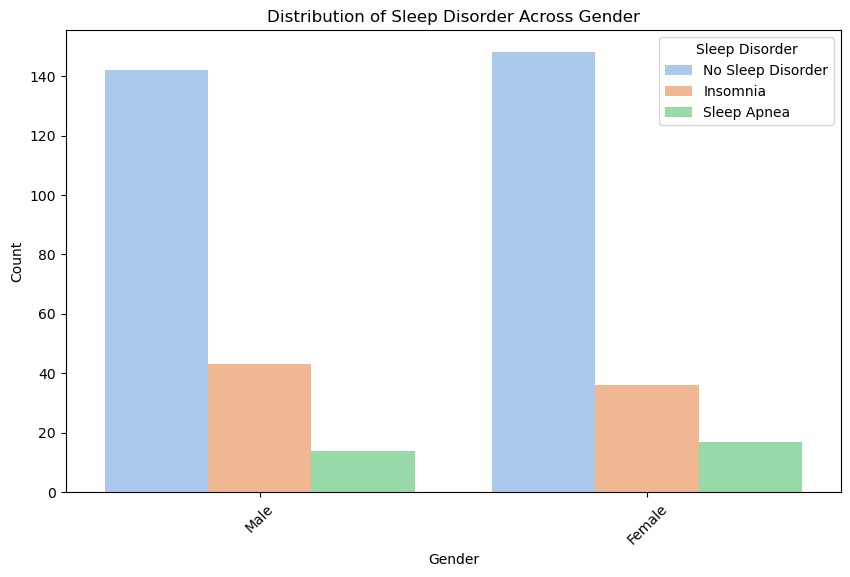

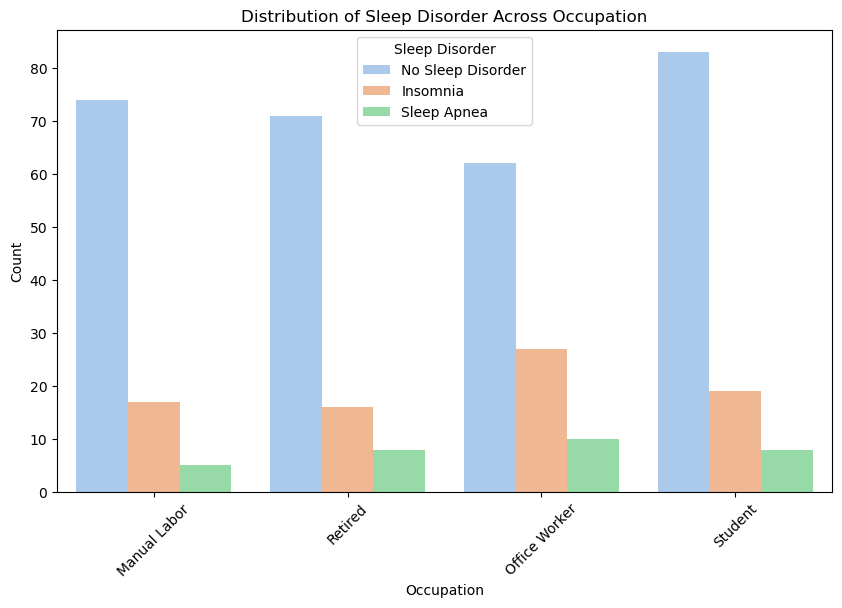

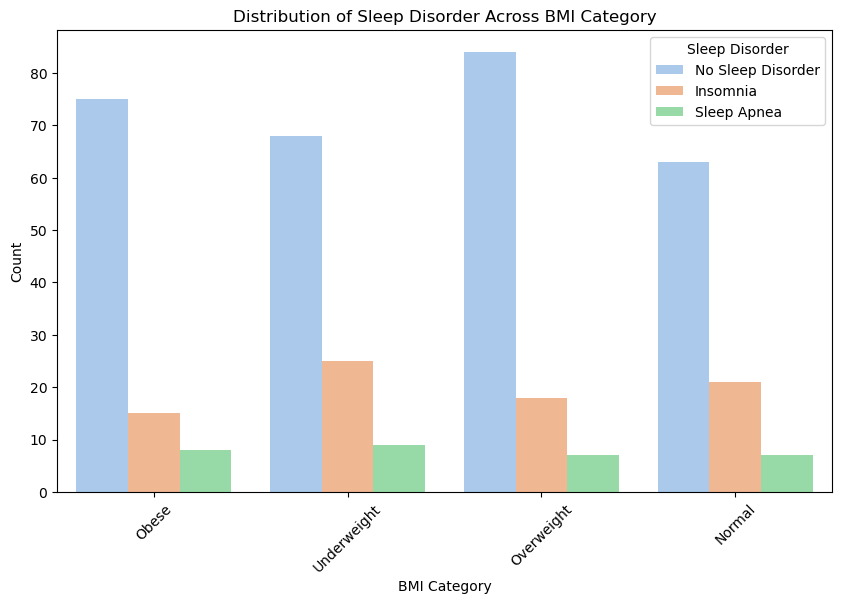

In [18]:
print("\n🔍 Analyzing the Distribution of Sleep Disorders Across Categories:")

categorical_features = ['Gender', 'Occupation', 'BMI Category']

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=sleep_df, x=feature, hue='Sleep Disorder', palette="pastel")
    plt.title(f"Distribution of Sleep Disorder Across {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Sleep Disorder")
    plt.xticks(rotation=45)
    plt.show()

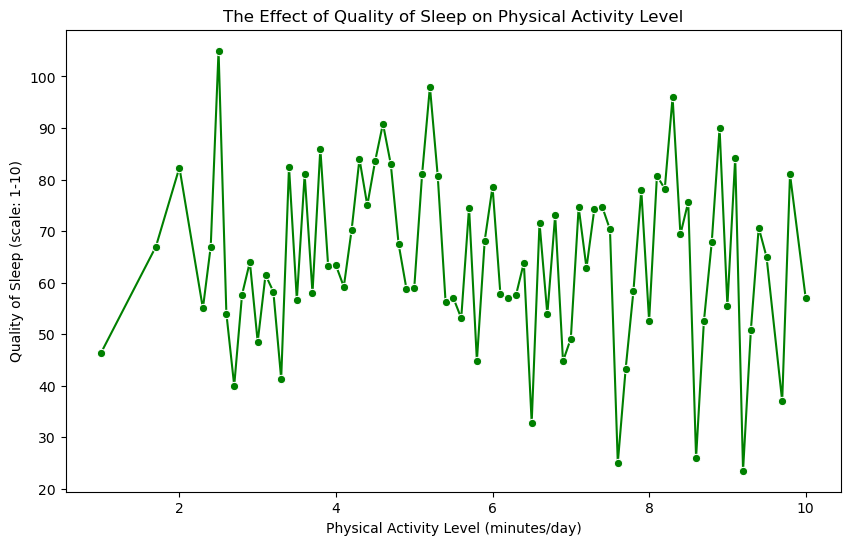

In [19]:
# Group by 'Sleep Quality' and calculate mean Physical Activity
avg_physical_activity = sleep_df.groupby('Quality of Sleep (scale: 1-10)')['Physical Activity Level (minutes/day)'].mean().reset_index()

# Plot Line Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(x='Quality of Sleep (scale: 1-10)', y='Physical Activity Level (minutes/day)', data=avg_physical_activity, marker='o', color='green')
plt.title('The Effect of Quality of Sleep on Physical Activity Level')
plt.xlabel('Physical Activity Level (minutes/day)')
plt.ylabel('Quality of Sleep (scale: 1-10)')
plt.grid(False)
plt.show()


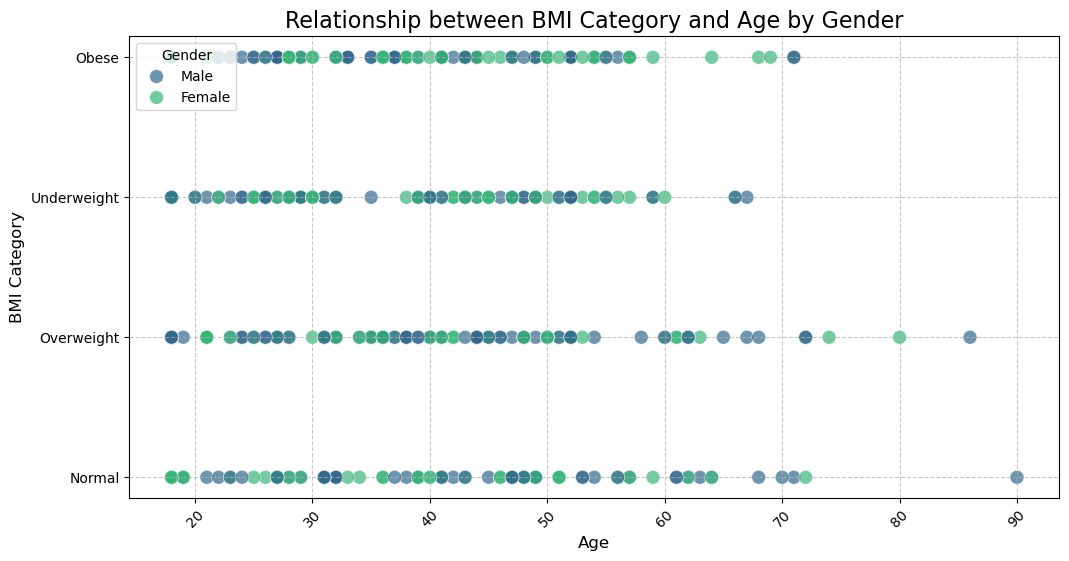

In [20]:
plt.figure(figsize=(12, 6))

scatter_plot = sns.scatterplot(x='Age', 
                               y='BMI Category', 
                               data=sleep_df, 
                               hue='Gender', 
                               palette='viridis', 
                               s=100,
                               edgecolor='w', 
                               alpha=0.7, 
                               linewidth=0.5)
plt.xticks(rotation=45)

plt.title('Relationship between BMI Category and Age by Gender', 
          fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('BMI Category', fontsize=12)
plt.legend(title='Gender', fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

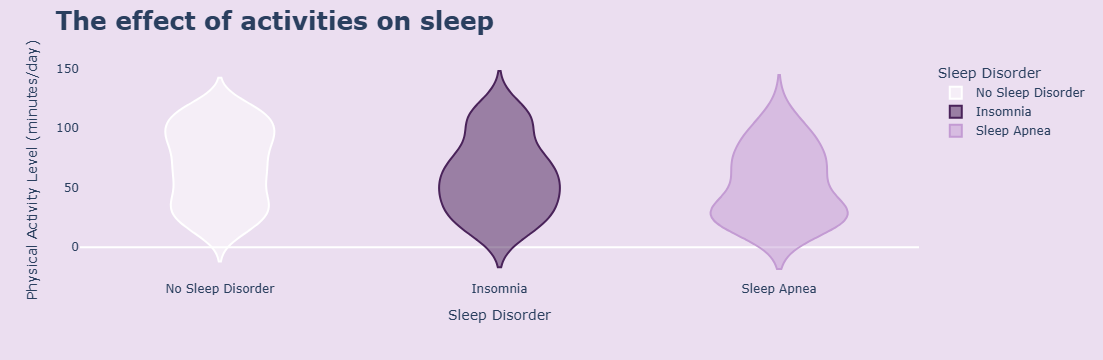

In [21]:
import plotly.express as px

fig = px.violin(sleep_df, x="Sleep Disorder", y='Physical Activity Level (minutes/day)',
                 color='Sleep Disorder',
                 color_discrete_sequence=['white', '#4A235A', '#C39BD3'],
                 violinmode='overlay')

fig.update_layout(title='<b>The effect of activities on sleep</b>',
                  title_font={'size': 25},
                  paper_bgcolor='#EBDEF0',
                  plot_bgcolor='#EBDEF0')

fig.update_yaxes(showgrid=False)

fig.show()



🤝 Visualizing Pairwise Relationships:


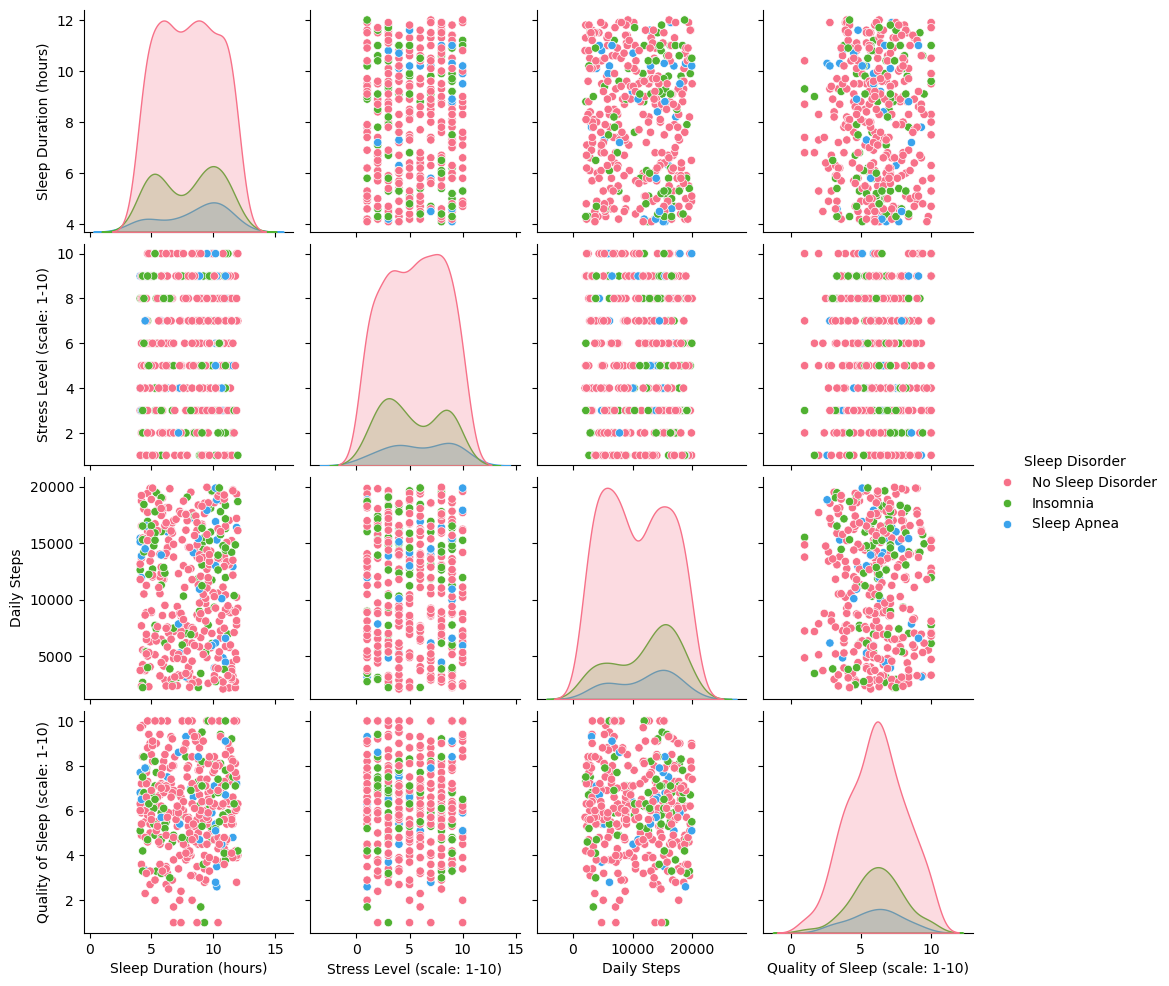

In [22]:
print("\n🤝 Visualizing Pairwise Relationships:")
# Select key features for pairplot
selected_features = [
    'Sleep Duration (hours)', 
    'Stress Level (scale: 1-10)', 
    'Daily Steps', 
    'Quality of Sleep (scale: 1-10)'
]

sns.pairplot(
    sleep_df[selected_features + ['Sleep Disorder']], 
    diag_kind="kde", 
    hue="Sleep Disorder", 
    palette="husl"
)
plt.show()


🤯 Analyzing Stress Levels Across Occupations:


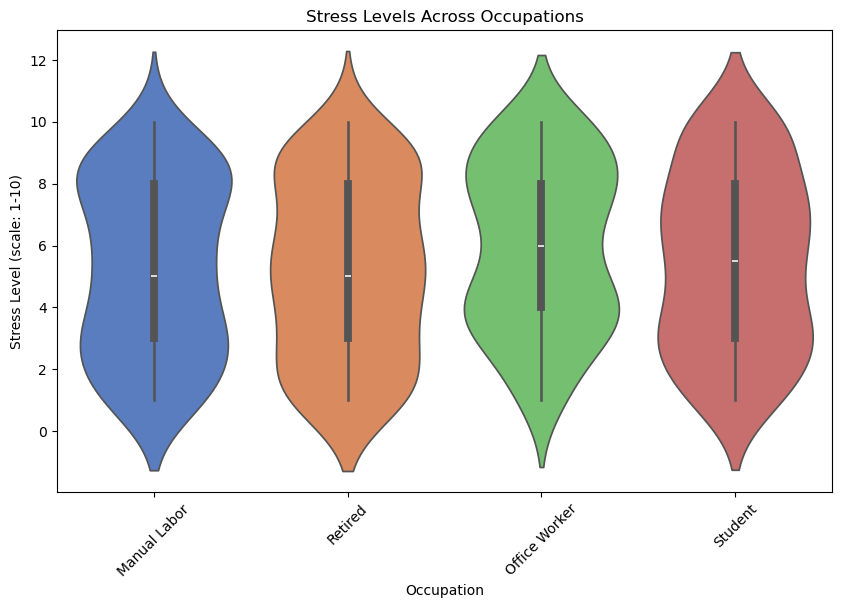

In [23]:
print("\n🤯 Analyzing Stress Levels Across Occupations:")

plt.figure(figsize=(10, 6))
sns.violinplot(data=sleep_df, x='Occupation', y='Stress Level (scale: 1-10)', palette="muted")
plt.title("Stress Levels Across Occupations")
plt.xlabel("Occupation")
plt.ylabel("Stress Level (scale: 1-10)")
plt.xticks(rotation=45)
plt.show()


 Correlation Analysis:


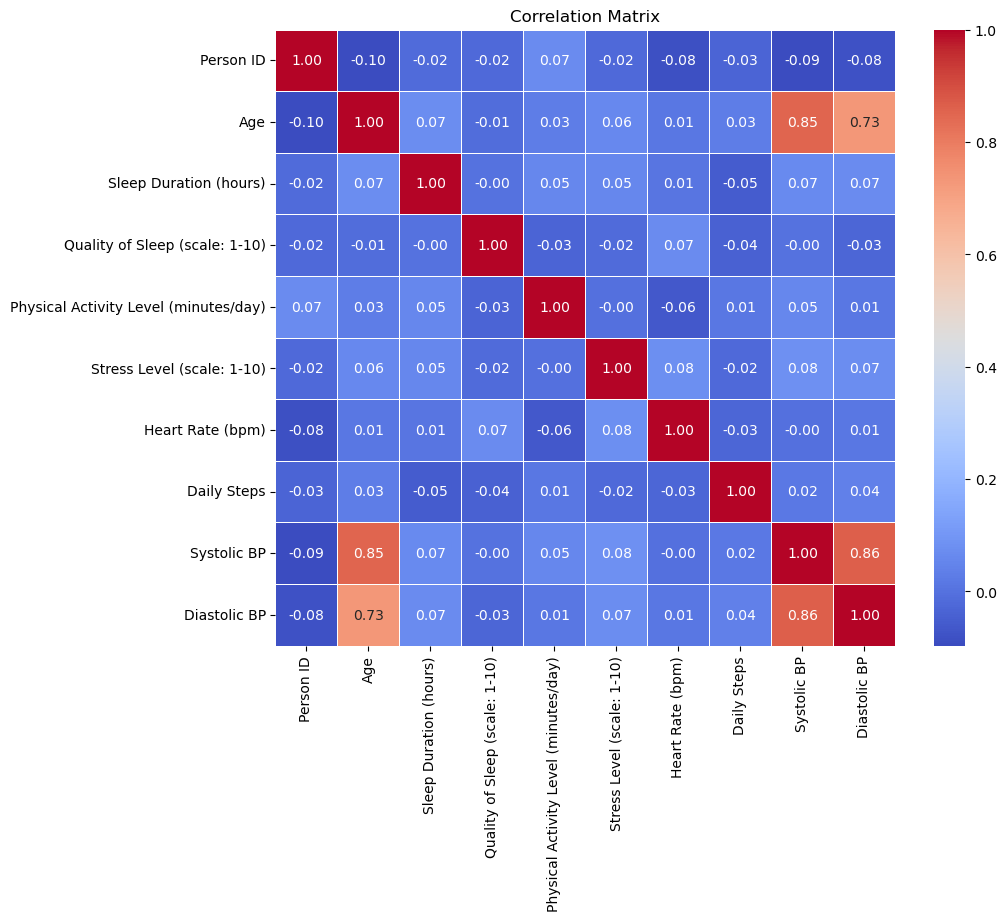

In [24]:
print("\n Correlation Analysis:")

# Select only numerical columns for correlation matrix
numerical_columns = sleep_df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numerical_columns.corr()

# Visualize the correlations using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [25]:
sleep_df.drop(columns=['Person ID'],axis = 1,inplace = True)


In [26]:
sleep_df.head()

,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Heart Rate (bpm),Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,29,Manual Labor,7.4,7.0,41,7,Obese,91,8539,No Sleep Disorder,124.0,70.0
1,Female,43,Retired,4.2,4.9,41,5,Obese,81,18754,No Sleep Disorder,131.0,86.0
2,Male,44,Retired,6.1,6.0,107,4,Underweight,81,2857,No Sleep Disorder,122.0,70.0
3,Male,29,Office Worker,8.3,10.0,20,10,Obese,55,6886,No Sleep Disorder,124.0,72.0
4,Male,67,Retired,9.1,9.5,19,4,Overweight,97,14945,Insomnia,133.0,78.0


In [27]:
num = sleep_df.select_dtypes(exclude='object')
cat = sleep_df.select_dtypes(include='object')

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical = cat.apply(lambda x : le.fit_transform(x))

In [29]:
categorical

,Gender,Occupation,BMI Category,Sleep Disorder
0,1,0,1,1
1,0,2,1,1
2,1,2,3,1
3,1,1,1,1
4,1,2,2,0
...,...,...,...,...
395,0,3,0,2
396,0,0,1,0
397,0,3,1,0
398,0,2,1,2


In [30]:
num.skew()

Age                                      0.435555
Sleep Duration (hours)                  -0.063774
Quality of Sleep (scale: 1-10)          -0.117204
Physical Activity Level (minutes/day)    0.038031
Stress Level (scale: 1-10)              -0.020582
Heart Rate (bpm)                        -0.085090
Daily Steps                             -0.078851
Systolic BP                              0.309746
Diastolic BP                             0.412774
dtype: float64

In [31]:
new_df = pd.concat([num,categorical],axis=1)

In [32]:
new_df

,Age,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),Heart Rate (bpm),Daily Steps,Systolic BP,Diastolic BP,Gender,Occupation,BMI Category,Sleep Disorder
0,29,7.4,7.0,41,7,91,8539,124.0,70.0,1,0,1,1
1,43,4.2,4.9,41,5,81,18754,131.0,86.0,0,2,1,1
2,44,6.1,6.0,107,4,81,2857,122.0,70.0,1,2,3,1
3,29,8.3,10.0,20,10,55,6886,124.0,72.0,1,1,1,1
4,67,9.1,9.5,19,4,97,14945,133.0,78.0,1,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,36,4.5,7.9,73,7,64,14497,118.0,66.0,0,3,0,2
396,45,6.0,6.1,72,8,65,12848,132.0,80.0,0,0,1,0
397,30,5.3,6.5,58,10,66,15255,125.0,76.0,0,3,1,0
398,41,11.0,9.1,73,9,75,6567,130.0,75.0,0,2,1,2


In [33]:
X = new_df.drop(['Sleep Disorder'], axis=1)
y = new_df['Sleep Disorder']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(320, 12) (80, 12)
(320,) (80,)


In [35]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier  # You may need to install xgboost using pip install xgboost

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Random Forest
# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

#GradientBoosting
# Initialize the model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
print("Gradient Boosting:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb))

Logistic Regression:
Accuracy: 0.7375
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.74      1.00      0.85        59
           2       0.00      0.00      0.00         4

    accuracy                           0.74        80
   macro avg       0.25      0.33      0.28        80
weighted avg       0.54      0.74      0.63        80

Random Forest:
Accuracy: 0.7500
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.75      1.00      0.86        59
           2       0.00      0.00      0.00         4

    accuracy                           0.75        80
   macro avg       0.58      0.35      0.32        80
weighted avg       0.76      0.75      0.65        80

Gradient Boosting:
Accuracy: 0.7000
              precision    recall  f1-score   support

           0       0.20      0.06      0.09        17
           1       0.74

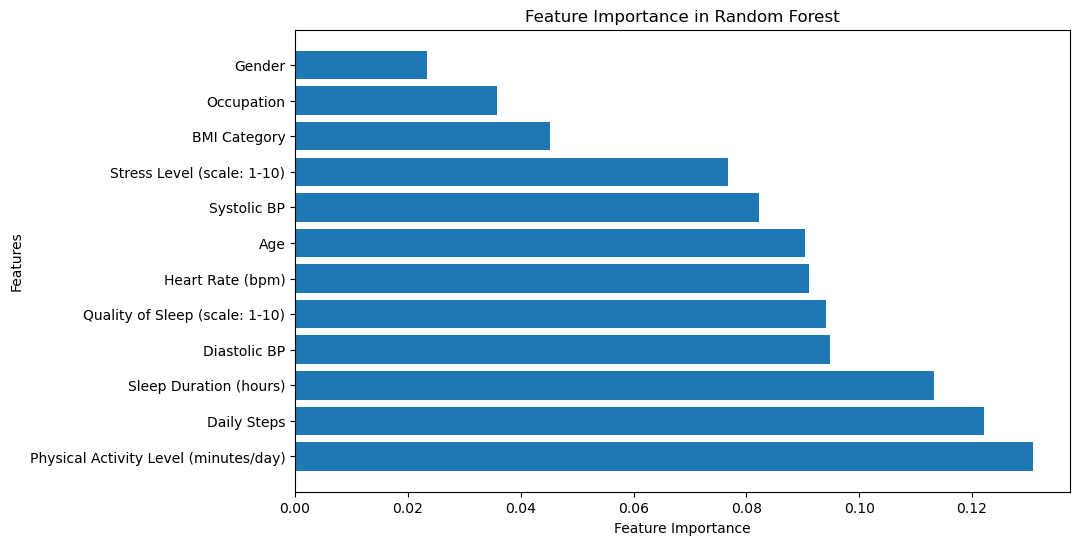

In [37]:
import pandas as pd

# Get Feature Importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.show()


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
best_model = grid_search.best_estimator_


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters:  {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [39]:
import pickle

In [40]:
with open("build2.pkl", "wb") as file:
    pickle.dump(best_model, file)